**A Star Algorthm**

Grid:
[0, 0, 0, 0, 0]
[0, 1, 1, 0, 0]
[0, 0, 0, 0, 0]
[0, 1, 0, 1, 0]
[0, 0, 0, 0, 0]

Path found:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]
Path length: 8


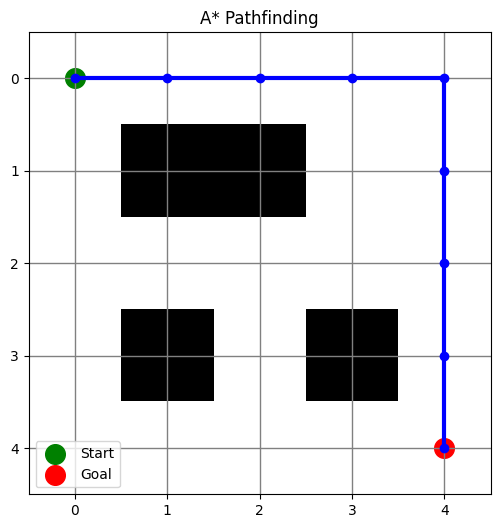

In [2]:
import heapq
import matplotlib.pyplot as plt

# Create the grid
# 0 = free cell
# 1 = obstacle
grid = [
    [0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (4, 4)


# Manhattan distance heuristic
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


# A* algorithm
def astar(graph, start, goal):
    rows = len(graph)
    cols = len(graph[0])

    # Priority queue
    open_list = []
    heapq.heappush(open_list, (0, start))

    # Stores the previous node for each node
    came_from = {}

    # Cost from start to each node
    g_score = {start: 0}

    # Estimated total cost
    f_score = {
        start: heuristic(start, goal)
    }

    # Up, down, left, right
    directions = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1)
    ]

    while open_list:

        # Get node with lowest f_score
        current_f, current = heapq.heappop(open_list)

        # Goal reached
        if current == goal:
            path = []

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.append(start)
            path.reverse()

            return path

        r, c = current

        # Check all neighboring cells
        for dr, dc in directions:
            nr = r + dr
            nc = c + dc

            # Check whether the neighbor is inside the grid
            # and is not an obstacle
            if (
                0 <= nr < rows
                and 0 <= nc < cols
                and graph[nr][nc] == 0
            ):
                neighbor = (nr, nc)

                # Cost of moving to neighbor
                tentative_g = g_score[current] + 1

                # If this is a better path
                if (
                    neighbor not in g_score
                    or tentative_g < g_score[neighbor]
                ):
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g

                    f = tentative_g + heuristic(neighbor, goal)
                    f_score[neighbor] = f

                    heapq.heappush(
                        open_list,
                        (f, neighbor)
                    )

    # No path found
    return None


# Run A*
path = astar(grid, start, goal)

print("Grid:")
for row in grid:
    print(row)

if path:
    print("\nPath found:")
    print(path)
    print("Path length:", len(path) - 1)
else:
    print("\nNo path found.")


# -------------------------
# Visualize the result
# -------------------------

plt.figure(figsize=(6, 6))

# Display grid
plt.imshow(grid, cmap="binary")

# Draw grid lines
plt.xticks(range(len(grid[0])))
plt.yticks(range(len(grid)))
plt.grid(True, color="gray", linewidth=1)

# Draw the path
if path:
    path_rows = [p[0] for p in path]
    path_cols = [p[1] for p in path]

    plt.plot(
        path_cols,
        path_rows,
        color="blue",
        linewidth=3,
        marker="o"
    )

# Mark start
plt.scatter(
    start[1],
    start[0],
    color="green",
    s=200,
    label="Start"
)

# Mark goal
plt.scatter(
    goal[1],
    goal[0],
    color="red",
    s=200,
    label="Goal"
)

plt.title("A* Pathfinding")
plt.legend()
plt.show()

In [3]:
import heapq

# Goal state
GOAL = (1, 2, 3,
        4, 5, 6,
        7, 8, 0)

# Possible movements of the blank tile
MOVES = {
    'Up': (-1, 0),
    'Down': (1, 0),
    'Left': (0, -1),
    'Right': (0, 1)
}


# Manhattan distance heuristic
def heuristic(state):
    distance = 0

    for i, value in enumerate(state):
        if value == 0:
            continue

        goal_index = GOAL.index(value)

        row1, col1 = divmod(i, 3)
        row2, col2 = divmod(goal_index, 3)

        distance += abs(row1 - row2) + abs(col1 - col2)

    return distance


# Generate neighboring states
def get_neighbors(state):
    neighbors = []

    zero_index = state.index(0)
    row, col = divmod(zero_index, 3)

    for move, (dr, dc) in MOVES.items():
        new_row = row + dr
        new_col = col + dc

        if 0 <= new_row < 3 and 0 <= new_col < 3:
            new_index = new_row * 3 + new_col

            new_state = list(state)
            new_state[zero_index], new_state[new_index] = \
                new_state[new_index], new_state[zero_index]

            neighbors.append((tuple(new_state), move))

    return neighbors


# Check whether puzzle is solvable
def is_solvable(state):
    numbers = [x for x in state if x != 0]
    inversions = 0

    for i in range(len(numbers)):
        for j in range(i + 1, len(numbers)):
            if numbers[i] > numbers[j]:
                inversions += 1

    return inversions % 2 == 0


# A* algorithm
def a_star(start):
    if not is_solvable(start):
        return None

    # Priority queue: (f, g, state, path)
    # f(n) = g(n) + h(n)
    pq = []
    heapq.heappush(pq, (heuristic(start), 0, start, []))

    visited = set()

    while pq:
        f, g, state, path = heapq.heappop(pq)

        if state in visited:
            continue

        visited.add(state)

        # Goal reached
        if state == GOAL:
            return path

        for next_state, move in get_neighbors(state):
            if next_state not in visited:
                new_g = g + 1
                new_f = new_g + heuristic(next_state)

                heapq.heappush(
                    pq,
                    (new_f, new_g, next_state, path + [move])
                )

    return None


# Print puzzle
def print_puzzle(state):
    for i in range(0, 9, 3):
        print(state[i:i + 3])
    print()


# Main program
start = (1, 2, 3,
         4, 0, 6,
         7, 5, 8)

print("Initial State:")
print_puzzle(start)

solution = a_star(start)

if solution is None:
    print("No solution exists.")
else:
    print("Solution found!")
    print("Number of moves:", len(solution))
    print("Moves:", solution)

    current = start

    print("\nSteps:")

    print_puzzle(current)

    for move in solution:
        zero_index = current.index(0)
        row, col = divmod(zero_index, 3)
        dr, dc = MOVES[move]

        new_row = row + dr
        new_col = col + dc
        new_index = new_row * 3 + new_col

        current = list(current)
        current[zero_index], current[new_index] = \
            current[new_index], current[zero_index]
        current = tuple(current)

        print("Move:", move)
        print_puzzle(current)

Initial State:
(1, 2, 3)
(4, 0, 6)
(7, 5, 8)

Solution found!
Number of moves: 2
Moves: ['Down', 'Right']

Steps:
(1, 2, 3)
(4, 0, 6)
(7, 5, 8)

Move: Down
(1, 2, 3)
(4, 5, 6)
(7, 0, 8)

Move: Right
(1, 2, 3)
(4, 5, 6)
(7, 8, 0)

